# Assignment 3: Milestone I - Natural Language Processing
## Task 1. Basic Text Pre-processing
#### Group: UN_Group 3
#### Student Name:
- Mai Dang Khoa ( s3974876 )
- Dang Cuu Dang Khoa ( s3979159 )
- Tran Quang Minh ( s3988776 )

Environment: Python 3 + Jupyter Notebook

Libraries used:
* pandas
* re
* collections (Counter)
* matplotlib

## Introduction
This notebook performs basic text pre-processing on the `review_text` column
of `cosmetics_beauty_products_reviews.csv` (61,284 reviews). The pipeline
tokenizes, lowercases, removes short tokens, stopwords, hapaxes (corpus
frequency = 1), and the 20 most frequent tokens by document frequency.
Outputs are `processed.csv` (cleaned `review_text` column) and `vocab.txt`
(alphabetical `word:index`).

## Importing libraries 

In [41]:
import os
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100
OUTPUT_DIR = "../output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 1.1 Examining and loading data
Inspect the `review_text` column - total count, missing values, and length
distribution before pre-processing.


In [42]:
df = pd.read_csv("../cosmetics_beauty_products_reviews.csv")

review_text = df["review_text"].fillna("")
print(f"Total reviews        : {len(df):,}")
print(f"Missing review_text  : {df['review_text'].isna().sum()}")
print(f"Empty after strip    : {(review_text.str.strip() == '').sum()}")
print(f"Mean length (chars)  : {review_text.str.len().mean():.0f}")
print(f"Median length (chars): {review_text.str.len().median():.0f}")

df[["review_id", "review_text"]].head(3)

Total reviews        : 61,284
Missing review_text  : 9
Empty after strip    : 9
Mean length (chars)  : 116
Median length (chars): 87


,review_id,review_text
0,16752142,Works as it claims. Could see the difference f...
1,14682550,It does what it claims . Best thing is it smoo...
2,15618995,I have been using this product for months now....


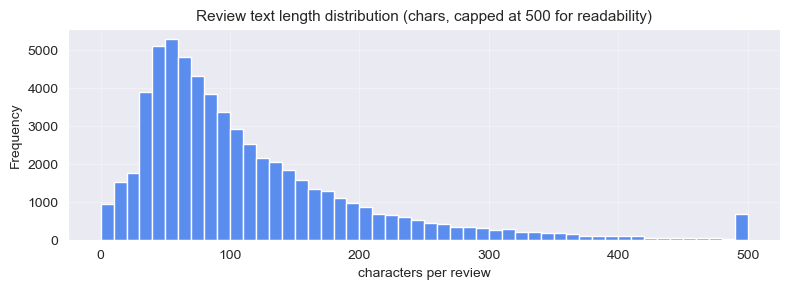

In [43]:
lengths = df["review_text"].fillna("").str.len()
ax = lengths.clip(upper=500).plot(kind="hist", bins=50, figsize=(8, 3), color="#5B8DEF")
ax.set_title("Review text length distribution (chars, capped at 500 for readability)", fontsize=11)
ax.set_xlabel("characters per review")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 1.2 Pre-processing data
The seven filtering steps required by the spec are applied in order. After each
step we record `(total_tokens, unique_tokens, avg_tokens_per_review)` so the
pipeline timeline at the end can visualise the reduction.

1. Extract `review_text`
2. Tokenize with regex `[a-zA-Z]+(?:[-'][a-zA-Z]+)?`
3. Lowercase
4. Remove tokens with length < 2
5. Remove stopwords (from `stopwords_en.txt`)
6. Remove tokens whose corpus term frequency = 1
7. Remove top-20 tokens by document frequency

After each step we record corpus-level stats (total tokens, unique tokens) so we
can chart the reduction at the end.


#### Tracker setup

In [44]:
pipeline_stats = []

def record(stage):
    total = sum(len(r) for r in tokenized)
    unique = len({t for r in tokenized for t in r})
    pipeline_stats.append({
        "stage": stage,
        "total_tokens": total,
        "unique_tokens": unique,
        "avg_tokens_per_review": round(total / max(len(tokenized), 1), 2),
    })

#### Step 1–2: Extract and tokenize

In [45]:
raw_reviews = df["review_text"].fillna("").tolist()

TOKEN_RE = re.compile(r"[a-zA-Z]+(?:[-'][a-zA-Z]+)?")
tokenized = [TOKEN_RE.findall(text) for text in raw_reviews]

record("1. tokenize")
print(f"Number of reviews: {len(tokenized):,}")
print(f"Sample (review 0): {tokenized[0][:20]}")

Number of reviews: 61,284
Sample (review 0): ['Works', 'as', 'it', 'claims', 'Could', 'see', 'the', 'difference', 'from', 'the', 'first', 'day', 'Use', 'it', 'with', 'Olay', 'cleanser', 'for', 'best', 'results']


#### Step 3: Lowercase

In [46]:
tokenized = [[tok.lower() for tok in review] for review in tokenized]
record("2. lowercase")
print(f"Sample after lowercase: {tokenized[0][:20]}")


Sample after lowercase: ['works', 'as', 'it', 'claims', 'could', 'see', 'the', 'difference', 'from', 'the', 'first', 'day', 'use', 'it', 'with', 'olay', 'cleanser', 'for', 'best', 'results']


#### Step 4: Remove tokens with length < 2

In [47]:
tokenized = [[tok for tok in review if len(tok) >= 2] for review in tokenized]
record("3. length≥2")
print(f"Sample after length filter: {tokenized[0][:20]}")

Sample after length filter: ['works', 'as', 'it', 'claims', 'could', 'see', 'the', 'difference', 'from', 'the', 'first', 'day', 'use', 'it', 'with', 'olay', 'cleanser', 'for', 'best', 'results']


#### Step 5: Remove stopwords

In [48]:
with open("../stopwords_en.txt", "r", encoding="utf-8") as f:
    stopwords = {line.strip() for line in f if line.strip()}

print(f"Stopwords loaded: {len(stopwords)}")

tokenized = [[tok for tok in review if tok not in stopwords] for review in tokenized]
record("4. stopwords")
print(f"Sample after stopword removal: {tokenized[0][:20]}")

Stopwords loaded: 570
Sample after stopword removal: ['works', 'claims', 'difference', 'day', 'olay', 'cleanser', 'results']


#### Step 6: Remove tokens whose corpus term frequency = 1

In [49]:
term_freq = Counter(tok for review in tokenized for tok in review)
hapaxes = {tok for tok, count in term_freq.items() if count == 1}
print(f"Hapaxes (term frequency == 1): {len(hapaxes):,}")

tokenized = [[tok for tok in review if tok not in hapaxes] for review in tokenized]
record("5. hapax")
print(f"Vocab size after hapax removal: {len({t for r in tokenized for t in r}):,}")

Hapaxes (term frequency == 1): 7,734
Vocab size after hapax removal: 8,074


#### Step 7: Remove top-20 tokens by document frequency

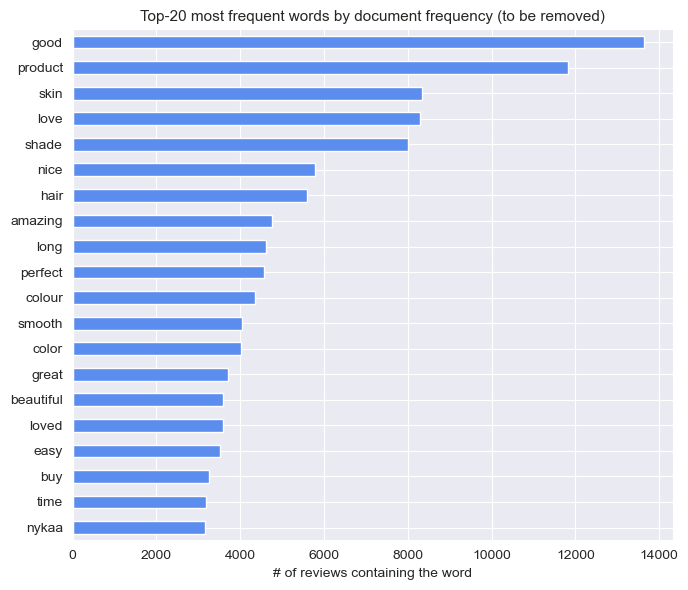

Vocab size after top-20 removal: 8,054


In [50]:
doc_freq = Counter()
for review in tokenized:
    doc_freq.update(set(review))

top20 = doc_freq.most_common(20)
top20_set = {tok for tok, _ in top20}

# Chart
top20_df = pd.DataFrame(top20, columns=["word", "doc_freq"]).iloc[::-1]
ax = top20_df.plot.barh(x="word", y="doc_freq", figsize=(7, 6),
                         color="#5B8DEF", legend=False)
ax.set_title("Top-20 most frequent words by document frequency (to be removed)", fontsize=11)
ax.set_xlabel("# of reviews containing the word")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

# Apply
tokenized = [[tok for tok in review if tok not in top20_set] for review in tokenized]
record("6. top-20 DF")
print(f"Vocab size after top-20 removal: {len({t for r in tokenized for t in r}):,}")


#### Pipeline timeline
Total token count and vocabulary size after each preprocessing step.

Token-count reduction at each step:


,stage,total_tokens,unique_tokens,avg_tokens_per_review
0,1. tokenize,1321300,20564,21.56
1,2. lowercase,1321300,16327,21.56
2,3. length≥2,1249277,16301,20.39
3,4. stopwords,569487,15808,9.29
4,5. hapax,561753,8074,9.17
5,6. top-20 DF,434032,8054,7.08


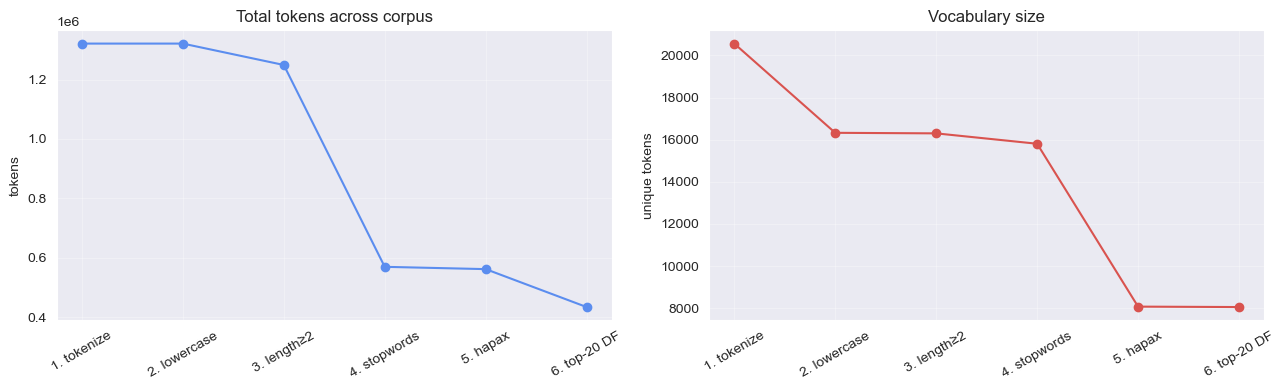

In [51]:
stats_df = pd.DataFrame(pipeline_stats)
print("Token-count reduction at each step:")
display(stats_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(stats_df["stage"], stats_df["total_tokens"], marker="o", color="#5B8DEF")
axes[0].set_title("Total tokens across corpus")
axes[0].set_ylabel("tokens")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(alpha=0.3)

axes[1].plot(stats_df["stage"], stats_df["unique_tokens"], marker="o", color="#d9534f")
axes[1].set_title("Vocabulary size")
axes[1].set_ylabel("unique tokens")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Saving required outputs
Two files are produced:
- `processed.csv` - original 15 columns preserved; `review_text` overwritten with the cleaned, space-joined tokens.
- `vocab.txt` - alphabetical unigram vocabulary in `word:index` format, 0-indexed.

### Save `processed.csv`

In [52]:
df["review_text"] = [" ".join(review) for review in tokenized]
df.to_csv(os.path.join(OUTPUT_DIR, "../output/processed.csv"), index=False)

print(f"Saved processed.csv - shape: {df.shape}")

original_text = pd.read_csv("../cosmetics_beauty_products_reviews.csv")["review_text"]
preview = pd.DataFrame({
    "original":  original_text.head(5).fillna("").str.slice(0, 70) + "…",
    "processed": df["review_text"].head(5).fillna("").str.slice(0, 70) + "…",
})
preview

Saved processed.csv - shape: (61284, 15)


,original,processed
0,Works as it claims. Could see the difference f...,works claims difference day olay cleanser resu...
1,It does what it claims . Best thing is it smoo...,claims thing smoothens ur makes soft…
2,I have been using this product for months now....,months combination oily greasy absorbs quickly...
3,"i have an oily skin, while this whip acts as a...",oily whip acts base primer smoothens moisturis...
4,It's not that good. Please refresh try for oth...,refresh products…


In [54]:
empty_mask = df["review_text"].fillna("") == ""
total = len(df)
wiped = empty_mask.sum()
print(f"review_text fully wiped: {wiped:,} / {total:,} ({wiped/total*100:.1f}%)")

original_text = pd.read_csv("../cosmetics_beauty_products_reviews.csv")["review_text"]
orig_len = original_text.fillna("").str.len()

bins   = [0, 5, 10, 20, 50, 100, 1_000, 100_000]
labels = ["0-5", "6-10", "11-20", "21-50", "51-100", "101-1000", "1000+"]
buckets = pd.cut(orig_len, bins=bins, labels=labels, include_lowest=True)

wipe_table = (
    pd.crosstab(buckets, empty_mask, normalize="index")
    .rename(columns={False: "survived_%", True: "wiped_%"})
    * 100
).round(1)

print("\nWipe rate by original review_text length:")
display(wipe_table)

print("\nSample wiped originals:")
for idx in df.index[empty_mask][:8]:
    print(f"  row {idx}: {original_text.loc[idx]!r}")

review_text fully wiped: 1,911 / 61,284 (3.1%)

Wipe rate by original review_text length:


review_text,survived_%,wiped_%
review_text,,
0-5,11.5,88.5
6-10,33.6,66.4
11-20,63.5,36.5
21-50,96.1,3.9
51-100,99.6,0.4
101-1000,100.0,0.0
1000+,100.0,0.0



Sample wiped originals:
  row 32: 'Nice...'
  row 41: '👍'
  row 145: 'Good'
  row 235: 'G'
  row 239: '42'
  row 248: "It's a good product"
  row 249: 'ok'
  row 252: 'Good'


### Save `vocab.txt`

In [55]:
vocab = sorted({tok for review in tokenized for tok in review})

with open(os.path.join(OUTPUT_DIR, "vocab.txt"), "w", encoding="utf-8") as f:
    for idx, word in enumerate(vocab):
        f.write(f"{word}:{idx}\n")

print("vocab.txt written - size:", len(vocab))
print("\nFirst 10 entries:")
for idx, word in enumerate(vocab[:10]):
    print(f"  {word}:{idx}")

vocab.txt written - size: 8054

First 10 entries:
  aa:0
  aback:1
  abd:2
  abh:3
  ability:4
  abit:5
  abnormally:6
  abroad:7
  abs:8
  absent:9


## Sanity checks

In [57]:
assert not (set(vocab) & stopwords), "Stopword found in vocab"
assert not (set(vocab) & top20_set), "Top-20 word found in vocab"
assert not (set(vocab) & hapaxes), "Hapax found in vocab"
assert all(len(w) >= 2 for w in vocab), "Short token in vocab"
assert vocab == sorted(vocab), "Vocab is not alphabetical"
print("All sanity checks passed.")
print("Final vocab size:", len(vocab))

All sanity checks passed.
Final vocab size: 8054


## Summary
The pipeline applies the seven filters in the exact order specified by the
assignment: tokenize → lowercase → drop short tokens → drop stopwords → drop
hapaxes (corpus frequency = 1) → drop the top-20 by document frequency.

The pipeline timeline shows the largest reductions come from stopword removal
and hapax removal - the top-20 step is small in token count but removes very
common words like *good*, *product*, *skin*.

Outputs:
- `processed.csv` - original 15 columns preserved, `review_text` overwritten
  with the space-joined cleaned tokens.
- `vocab.txt` - alphabetical `word:index` entries, 0-indexed.